# Results analysis — F/T/S partition study

This notebook does two things:
1. **Brainstorm + document** what data to collect during training (reference for notebook 04).
2. **Prototype the full plotting pipeline** on synthetically generated results, so the plots
   are ready to receive real data from notebook 04 with zero changes.

---

## Data collection checklist

### Per-configuration (stored in `spectrum_experiment.csv`)
| Field | Description | Status |
|-------|-------------|--------|
| `label` | Compact config label (e.g. `F2T2S2`) | ✅ stored |
| `partition` | 6-tuple of F/T/S modes | ✅ stored |
| `frozen_depth` | `a` — number of frozen backbone blocks (0–5) | ✅ stored as `n_frozen` |
| `tuned_depth` | `b` — number of fine-tuned backbone blocks (0–5) | ✅ stored as `n_tuned` |
| `scratch_depth` | `c` — number of scratch backbone blocks (0–5) | ✅ stored as `n_scratch` |
| `scratch_start` | `a+b` — first block index where S begins (0=stem, 5=no backbone S) | ⚠️ derive from `n_frozen + n_tuned` |
| `trainable_params` | Number of updated weights | ✅ stored |
| `trainable_pct` | % of total params that are trainable | ✅ stored |
| `inference_flops_G` | FLOPs for one forward pass (constant across configs) | ✅ stored |
| `training_flops_G` | FLOPs per sample (fwd + proportional bwd) | ✅ stored |
| `total_training_GFLOPs` | `training_flops_G × n_train × n_epochs` — total compute | ⚠️ not yet stored |
| `elapsed_s` | Wall-clock training time | ✅ stored |
| `id_val_acc` / `bal_acc` / `f1` | ID validation performance | ✅ stored |
| `ood_val_acc` / `bal_acc` / `f1` | OOD validation performance | ✅ stored |
| `id_test_*` / `ood_test_*` | Hold-out test performance | ✅ stored |
| `id_ood_gap` | `id_bal_acc - ood_bal_acc` (generalisation gap) | ⚠️ derive |

### Per eval checkpoint (stored in `eval_log` list, **not yet saved to CSV**)
| Field | Description | Status |
|-------|-------------|--------|
| `step`, `epoch`, `elapsed_s` | Training position | ✅ in eval_log |
| `train_loss`, `train_acc` | Training set snapshot | ✅ in eval_log |
| `id_val_*`, `ood_val_*` | Validation metrics at checkpoint | ✅ in eval_log |
| **`grad_norm`** | L2 norm of all gradients — flags instability in F→S transitions (H4) | ❌ missing |
| **`lr`** | Current learning rate — sanity check for scheduler | ❌ missing |

### Per class (for N3 analysis — **not yet stored at all**)
| Field | Description | Status |
|-------|-------------|--------|
| `per_class_ood_acc` | Per-class accuracy on OOD test | ❌ missing |
| `rare_class_ood_gap` | Gap between common vs rare class OOD acc | ❌ missing |

### Action items for notebook 04
- Add `scratch_start = n_frozen + n_tuned` column to the results CSV.
- Add `total_training_GFLOPs = training_flops_G × n_train_samples × n_epochs` column.
- Save `eval_log` per config to a separate CSV (`eval_log_{label}.csv`) or a combined
  long-format CSV (`eval_log_all.csv`) so training curves are available for plotting.
- Add `grad_norm` logging in `train.py` (compute after `loss.backward()`, before `optimizer.step()`).
- Add per-class OOD accuracy in a post-hoc analysis step.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path.cwd().parent))
from models import enumerate_configs, config_label

RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi':      120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size':       10,
})

ALL_CONFIGS = enumerate_configs()
ALL_LABELS  = [config_label(p) for p in ALL_CONFIGS]
print(f'{len(ALL_CONFIGS)} configurations')

21 configurations


## Synthetic data generator

The formula encodes the expected story from the hypotheses:

- **ID**: driven by the amount of pretrained + fine-tuned capacity (`a×0.035 + b×0.075`).
  Early scratch penalises ID because untrained features propagate upward.
- **OOD**: frozen early layers preserve general, transferable features → frozen bonus
  peaks at `a=2` (Gaussian). Too much freezing (`a=5`) limits adaptation and hurts OOD;
  too little (`a=0`) over-fits to source domain. Early scratch wipes out pretrained
  representations → large OOD penalty.
- **Training time**: proportional to trainable parameter ratio (backward pass cost).
  Reflects the real ResNet50 block distribution (stage4 = 62.7% of params).
- **Training curves**: saturating exponential; scratch configs converge slower.

In [2]:
# ResNet50 parameter fraction per block (stem, s1, s2, s3, s4, head)
_BLOCK_PCT = [0.04, 0.90, 5.10, 29.73, 62.69, 1.53]

def _trainable_pct(partition):
    return sum(pct for pct, m in zip(_BLOCK_PCT, partition) if m in ('T', 'S'))


def generate_results(configs, labels, n_epochs=10, n_train=32000, seed=7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []

    for partition, label in zip(configs, labels):
        a = partition[:5].count('F')   # frozen_depth
        b = partition[:5].count('T')   # tuned_depth
        c = partition[:5].count('S')   # scratch_depth (backbone only)
        scratch_start = a + b          # first backbone block that is S

        # ── ID balanced accuracy ──────────────────────────────────────────────
        # Pretrained features (F and T) boost ID; T more than F (T adapts)
        id_pretrained   = a * 0.035 + b * 0.075
        # Scratch starting early propagates uninitialised features → hurts ID
        id_early_penalty = 0.05 * max(0, 3 - scratch_start) * (c / 5)
        id_bal = np.clip(0.28 + id_pretrained - id_early_penalty
                         + rng.normal(0, 0.012), 0.22, 0.80)

        # ── OOD balanced accuracy ─────────────────────────────────────────────
        # Frozen early layers preserve general features → OOD bonus peaks at a=2
        ood_frozen_bonus   = 0.11 * np.exp(-0.5 * ((a - 2) / 1.4) ** 2)
        ood_ft_bonus       = b * 0.038
        ood_scratch_penalty = 0.07 * max(0, 3 - scratch_start)
        ood_bal = np.clip(0.14 + ood_frozen_bonus + ood_ft_bonus - ood_scratch_penalty
                          + rng.normal(0, 0.012), 0.08, 0.65)

        # ── F1 scores ─────────────────────────────────────────────────────────
        id_f1  = round(float(np.clip(id_bal  * rng.uniform(0.86, 0.93), 0, 1)), 3)
        ood_f1 = round(float(np.clip(ood_bal * rng.uniform(0.81, 0.90), 0, 1)), 3)

        # ── Compute metrics ───────────────────────────────────────────────────
        tr_pct   = _trainable_pct(partition)
        tr_ratio = tr_pct / 100
        elapsed  = 400 + 900 * tr_ratio + rng.uniform(-15, 15)

        inf_flops = 8.2e9
        train_flops_sample = inf_flops * (1 + 2 * tr_ratio)
        total_gflops = train_flops_sample * n_train * n_epochs / 1e9

        rows.append({
            'label':               label,
            'frozen_depth':        a,
            'tuned_depth':         b,
            'scratch_depth':       c,
            'scratch_start':       scratch_start,
            'trainable_pct':       round(tr_pct, 1),
            'elapsed_s':           round(elapsed),
            'total_train_GFLOPs':  round(total_gflops),
            'id_val_bal_acc':      round(float(id_bal), 3),
            'ood_val_bal_acc':     round(float(ood_bal), 3),
            'id_val_f1':           id_f1,
            'ood_val_f1':          ood_f1,
            'id_ood_gap':          round(float(id_bal - ood_bal), 3),
        })

    return pd.DataFrame(rows).set_index('label')


def generate_curves(df, n_epochs=10, seed=7) -> pd.DataFrame:
    """Fake per-epoch eval logs for all configs."""
    rng  = np.random.default_rng(seed)
    rows = []
    for label in df.index:
        final_id  = df.loc[label, 'id_val_bal_acc']
        final_ood = df.loc[label, 'ood_val_bal_acc']
        # Scratch configs converge slower
        speed_factor = 0.3 + 0.5 * (df.loc[label, 'trainable_pct'] / 100)
        for e in range(1, n_epochs + 1):
            frac = 1 - np.exp(-speed_factor * e)
            rows.append({
                'label':          label,
                'epoch':          e,
                'id_val_bal_acc': round(final_id  * frac + rng.normal(0, 0.008), 3),
                'ood_val_bal_acc':round(final_ood * frac + rng.normal(0, 0.008), 3),
            })
    return pd.DataFrame(rows)


df     = generate_results(ALL_CONFIGS, ALL_LABELS)
curves = generate_curves(df)

df.to_csv(RESULTS / 'spectrum_experiment_synthetic.csv')
curves.to_csv(RESULTS / 'eval_log_all_synthetic.csv', index=False)
print(df[['frozen_depth','scratch_start','trainable_pct',
          'id_val_bal_acc','ood_val_bal_acc','id_ood_gap',
          'elapsed_s','total_train_GFLOPs']]
      .sort_values('ood_val_bal_acc', ascending=False).to_string())

        frozen_depth  scratch_start  trainable_pct  id_val_bal_acc  ood_val_bal_acc  id_ood_gap  elapsed_s  total_train_GFLOPs
label                                                                                                                         
F1T4S1             1              5          100.0           0.624            0.363       0.261       1289             7869376
F1T3S2             1              4          100.0           0.521            0.350       0.172       1295             7869376
F2T3S1             2              5           99.0           0.583            0.340       0.243       1302             7822144
T5S1               0              5          100.0           0.653            0.339       0.313       1300             7871475
F2T2S2             2              4           99.0           0.498            0.337       0.161       1297             7822144
T4S2               0              4          100.0           0.558            0.329       0.229       1286     

---
## Plots

In [3]:
# ── Shared colour conventions ─────────────────────────────────────────────────
# frozen_depth (a = 0..5) → cool-to-warm palette
FROZEN_CMAP  = plt.cm.RdYlBu_r
FROZEN_NORM  = mcolors.Normalize(vmin=0, vmax=5)
def frozen_color(a): return FROZEN_CMAP(FROZEN_NORM(a))

# scratch_start (a+b = 0..5) → marker style
SCRATCH_MARKERS = {0:'X', 1:'X', 2:'s', 3:'D', 4:'o', 5:'o'}
SCRATCH_LABELS  = {0:'early scratch (0–1)', 1:'early scratch (0–1)',
                   2:'mid scratch (2)', 3:'mid scratch (3)',
                   4:'late scratch (4–5)', 5:'late scratch (4–5)'}

# Highlight key configs
KEY_CONFIGS = {'S6', 'T5S1', 'F5S1', 'F2T2S2', 'F2T3S1'}

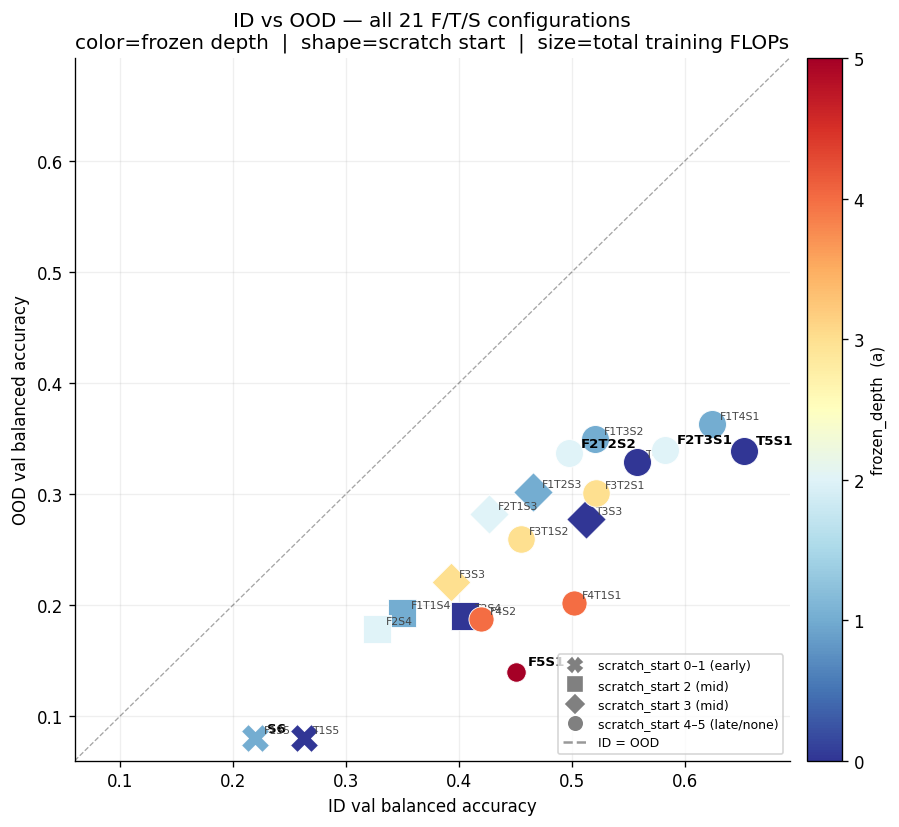

In [4]:
# ── Plot 1: Primary — ID vs OOD scatter ──────────────────────────────────────
# Color  = frozen_depth (how many early blocks are frozen)
# Marker = scratch_start category (how late does scratch begin)
# Size   = total training GFLOPs (compute invested)

fig, ax = plt.subplots(figsize=(8, 7))

for label in ALL_LABELS:
    row = df.loc[label]
    a   = int(row['frozen_depth'])
    ss  = int(row['scratch_start'])
    size = 60 + 220 * (row['total_train_GFLOPs'] / df['total_train_GFLOPs'].max())

    ax.scatter(row['id_val_bal_acc'], row['ood_val_bal_acc'],
               c=[frozen_color(a)], s=size,
               marker=SCRATCH_MARKERS[ss], zorder=3,
               edgecolors='white', linewidths=0.5)

    if label in KEY_CONFIGS:
        ax.annotate(label, (row['id_val_bal_acc'], row['ood_val_bal_acc']),
                    textcoords='offset points', xytext=(7, 4),
                    fontsize=8, fontweight='bold')
    else:
        ax.annotate(label, (row['id_val_bal_acc'], row['ood_val_bal_acc']),
                    textcoords='offset points', xytext=(5, 3), fontsize=6.5, color='#444')

# ID = OOD reference
lo = min(df[['id_val_bal_acc','ood_val_bal_acc']].min()) - 0.02
hi = max(df[['id_val_bal_acc','ood_val_bal_acc']].max()) + 0.04
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.35, label='ID = OOD')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

# Colorbar for frozen_depth
sm = plt.cm.ScalarMappable(cmap=FROZEN_CMAP, norm=FROZEN_NORM)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.02)
cb.set_label('frozen_depth  (a)', fontsize=9)
cb.set_ticks(range(6))

# Legend for marker shapes (scratch_start groups)
marker_handles = [
    Line2D([0],[0], marker='X', color='gray', ls='None', ms=8, label='scratch_start 0–1 (early)'),
    Line2D([0],[0], marker='s', color='gray', ls='None', ms=8, label='scratch_start 2 (mid)'),
    Line2D([0],[0], marker='D', color='gray', ls='None', ms=8, label='scratch_start 3 (mid)'),
    Line2D([0],[0], marker='o', color='gray', ls='None', ms=8, label='scratch_start 4–5 (late/none)'),
    Line2D([0],[0], ls='--', color='k', alpha=0.4, label='ID = OOD'),
]
ax.legend(handles=marker_handles, fontsize=7.5, loc='lower right')

ax.set_xlabel('ID val balanced accuracy')
ax.set_ylabel('OOD val balanced accuracy')
ax.set_title('ID vs OOD — all 21 F/T/S configurations\n'
             'color=frozen depth  |  shape=scratch start  |  size=total training FLOPs')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS / 'plot1_id_ood_scatter.png', bbox_inches='tight')
plt.show()

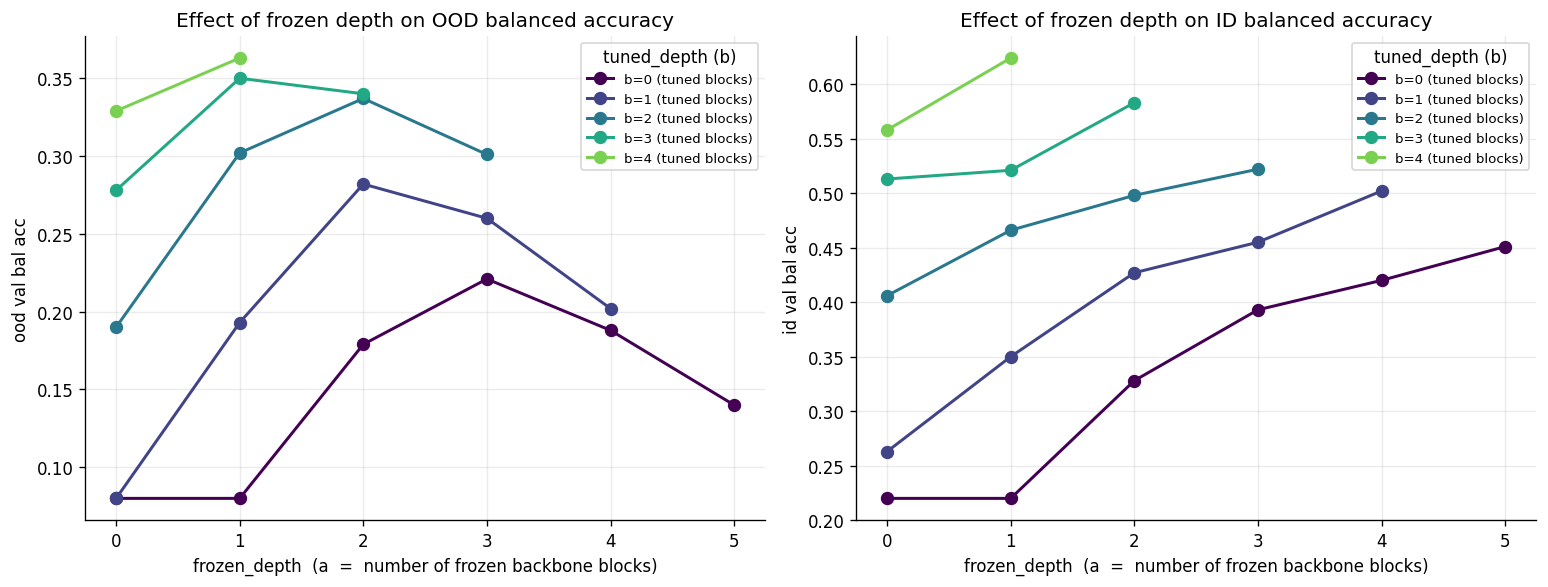

In [5]:
# ── Plot 2: Effect of frozen_depth on OOD — one line per tuned_depth ─────────
# Tests H1 (freezing early layers doesn't hurt) and H6 (frozen features boost OOD)
# Each line = configs with the same b (tuned_depth), varying a (0 to 5-b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

b_values = sorted(df['tuned_depth'].unique())
b_cmap   = plt.cm.viridis(np.linspace(0, 1, len(b_values)))

for metric, ax, title in [
    ('ood_val_bal_acc', axes[0], 'Effect of frozen depth on OOD balanced accuracy'),
    ('id_val_bal_acc',  axes[1], 'Effect of frozen depth on ID balanced accuracy'),
]:
    for b, color in zip(b_values, b_cmap):
        sub = df[df['tuned_depth'] == b].sort_values('frozen_depth')
        if len(sub) < 2:
            continue
        ax.plot(sub['frozen_depth'], sub[metric], 'o-',
                color=color, lw=1.8, ms=7, label=f'b={b} (tuned blocks)')

    ax.set_xlabel('frozen_depth  (a  =  number of frozen backbone blocks)')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(title)
    ax.set_xticks(range(6))
    ax.legend(fontsize=8, title='tuned_depth (b)')
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS / 'plot2_frozen_depth_effect.png', bbox_inches='tight')
plt.show()

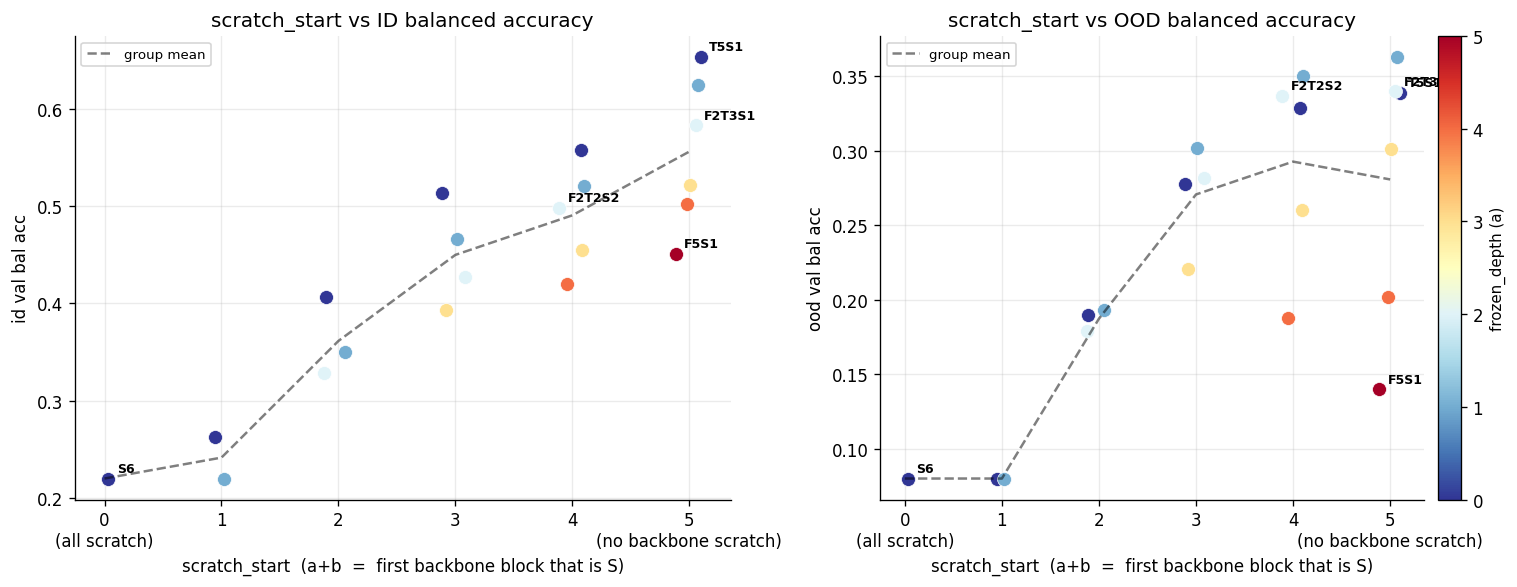

In [6]:
# ── Plot 3: Effect of scratch_start on ID — does delaying scratch help? ───────
# Tests H2 (top layers task-specific → scratching them is fine)
#       H8 (early scratch degrades performance)
# Each point = one config; x = scratch_start, y = ID bal acc
# Color = frozen_depth; strip-plot with jitter on x for readability

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for metric, ax, title in [
    ('id_val_bal_acc',  axes[0], 'scratch_start vs ID balanced accuracy'),
    ('ood_val_bal_acc', axes[1], 'scratch_start vs OOD balanced accuracy'),
]:
    rng = np.random.default_rng(0)
    for label in ALL_LABELS:
        row = df.loc[label]
        a   = int(row['frozen_depth'])
        jitter = rng.uniform(-0.12, 0.12)
        ax.scatter(row['scratch_start'] + jitter, row[metric],
                   c=[frozen_color(a)], s=70, zorder=3,
                   edgecolors='white', linewidths=0.4)
        if label in KEY_CONFIGS:
            ax.annotate(label, (row['scratch_start'] + jitter, row[metric]),
                        textcoords='offset points', xytext=(5, 4), fontsize=7.5, fontweight='bold')

    # Group means
    means = df.groupby('scratch_start')[metric].mean()
    ax.plot(means.index, means.values, 'k--', lw=1.5, alpha=0.5, zorder=4, label='group mean')

    ax.set_xlabel('scratch_start  (a+b  =  first backbone block that is S)')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(title)
    ax.set_xticks(range(6))
    ax.set_xticklabels(['0\n(all scratch)', '1', '2', '3', '4', '5\n(no backbone scratch)'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

sm = plt.cm.ScalarMappable(cmap=FROZEN_CMAP, norm=FROZEN_NORM)
sm.set_array([])
cb = plt.colorbar(sm, ax=axes[1], pad=0.02)
cb.set_label('frozen_depth (a)', fontsize=9)
cb.set_ticks(range(6))

plt.tight_layout()
plt.savefig(RESULTS / 'plot3_scratch_start_effect.png', bbox_inches='tight')
plt.show()

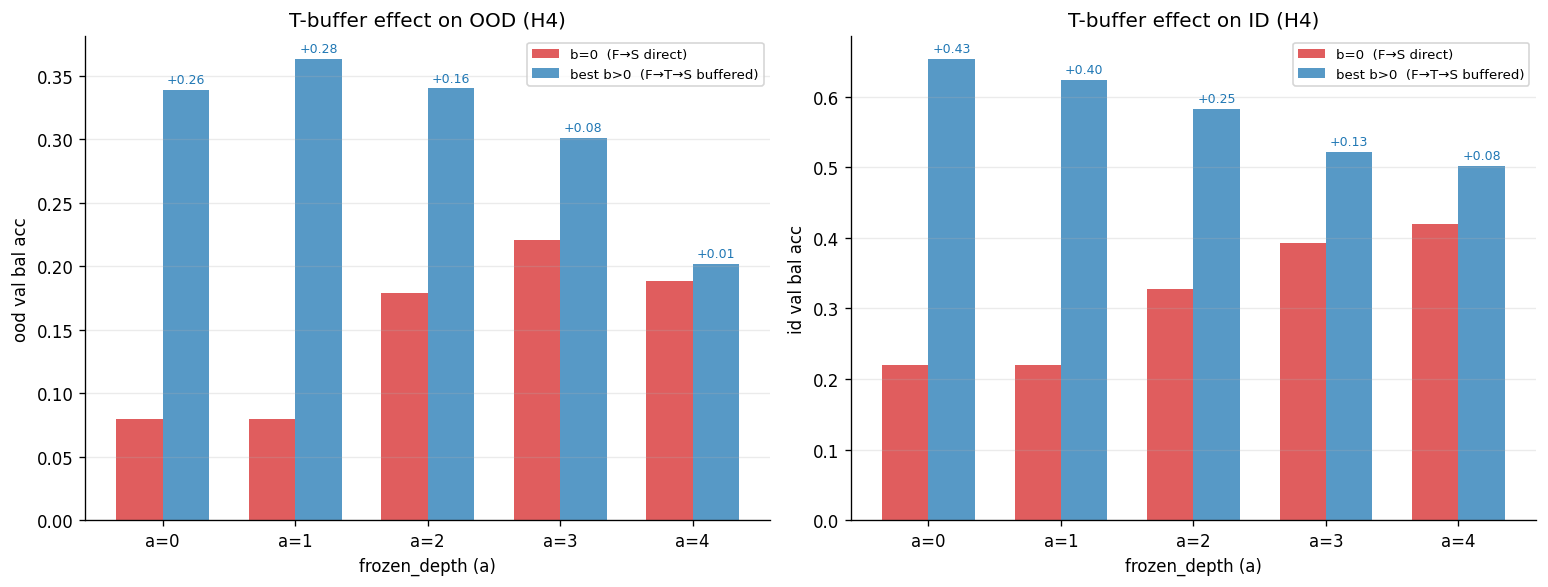

In [7]:
# ── Plot 4: T-buffer effect — H4 ─────────────────────────────────────────────
# For each (a, c) pair, compare configs with b=0 (direct F→S) vs b>0 (T buffer).
# If H4 is true, inserting T between F and S should improve performance.
# Show OOD balanced accuracy; group by frozen_depth.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for metric, ax, title in [
    ('ood_val_bal_acc', axes[0], 'T-buffer effect on OOD (H4)'),
    ('id_val_bal_acc',  axes[1], 'T-buffer effect on ID (H4)'),
]:
    # For each frozen_depth a, plot b=0 vs best b>0 at same a
    a_values = range(6)
    direct_ood = []   # b=0: F→S directly
    buffer_ood = []   # best b>0: F→T→S
    a_valid    = []

    for a in a_values:
        sub    = df[df['frozen_depth'] == a]
        direct = sub[sub['tuned_depth'] == 0]
        buffered = sub[sub['tuned_depth'] > 0]
        if len(direct) == 0 or len(buffered) == 0:
            continue
        direct_ood.append(direct[metric].values[0])
        buffer_ood.append(buffered[metric].max())
        a_valid.append(a)

    x = np.arange(len(a_valid))
    w = 0.35
    bars1 = ax.bar(x - w/2, direct_ood, w, label='b=0  (F→S direct)', color='#d62728', alpha=0.75)
    bars2 = ax.bar(x + w/2, buffer_ood, w, label='best b>0  (F→T→S buffered)', color='#1f77b4', alpha=0.75)

    # Gain arrows
    for xi, (d, buf) in zip(x, zip(direct_ood, buffer_ood)):
        gain = buf - d
        if gain > 0.005:
            ax.annotate(f'+{gain:.2f}', xy=(xi + w/2, buf),
                        textcoords='offset points', xytext=(0, 4),
                        ha='center', fontsize=7.5, color='#1f77b4')

    ax.set_xticks(x)
    ax.set_xticklabels([f'a={v}' for v in a_valid])
    ax.set_xlabel('frozen_depth (a)')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS / 'plot4_t_buffer_effect.png', bbox_inches='tight')
plt.show()

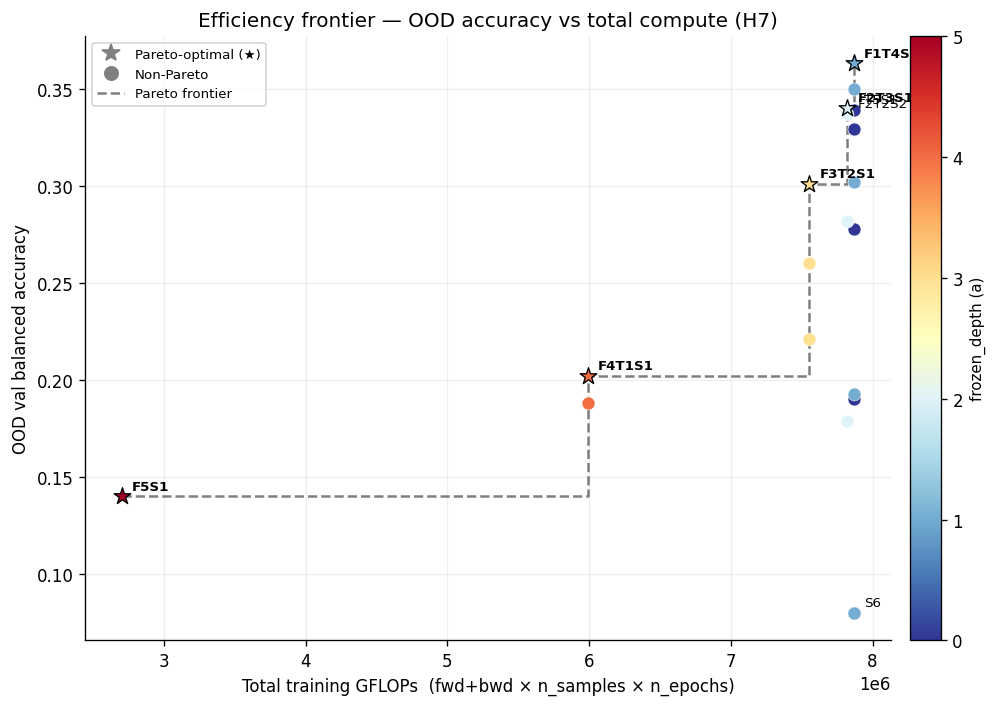

Pareto-optimal configs:
        frozen_depth  scratch_start  trainable_pct  ood_val_bal_acc  total_train_GFLOPs  elapsed_s
label                                                                                             
F1T4S1             1              5          100.0            0.363             7869376       1289
F2T3S1             2              5           99.0            0.340             7822144       1302
F3T2S1             3              5           94.0            0.301             7554496       1232
F4T1S1             4              5           64.2            0.202             5994266        992
F5S1               5              5            1.5            0.140             2704294        409


In [8]:
# ── Plot 5: Efficiency frontier — OOD vs total training FLOPs ─────────────────
# Tests H7 (good OOD at lower compute than full fine-tune)
# Pareto-optimal configs highlighted: no other config has both higher OOD and lower FLOPs

ood   = df['ood_val_bal_acc'].values
flops = df['total_train_GFLOPs'].values

pareto = np.ones(len(df), dtype=bool)
for i in range(len(df)):
    for j in range(len(df)):
        if i != j and ood[j] >= ood[i] and flops[j] <= flops[i] and not (ood[j] == ood[i] and flops[j] == flops[i]):
            pareto[i] = False
            break

fig, ax = plt.subplots(figsize=(9, 6))

for i, label in enumerate(ALL_LABELS):
    row = df.loc[label]
    a   = int(row['frozen_depth'])
    is_pareto = pareto[i]
    ax.scatter(row['total_train_GFLOPs'], row['ood_val_bal_acc'],
               c=[frozen_color(a)], s=110 if is_pareto else 60,
               marker='*' if is_pareto else 'o',
               zorder=4 if is_pareto else 3,
               edgecolors='black' if is_pareto else 'white',
               linewidths=0.8 if is_pareto else 0.3)
    if is_pareto or label in KEY_CONFIGS:
        ax.annotate(label,
                    (row['total_train_GFLOPs'], row['ood_val_bal_acc']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, fontweight='bold' if is_pareto else 'normal')

# Draw Pareto frontier
pareto_df = df[pareto].sort_values('total_train_GFLOPs')
ax.step(pareto_df['total_train_GFLOPs'], pareto_df['ood_val_bal_acc'],
        where='post', color='black', lw=1.5, alpha=0.5, ls='--', label='Pareto frontier')

sm = plt.cm.ScalarMappable(cmap=FROZEN_CMAP, norm=FROZEN_NORM)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.02)
cb.set_label('frozen_depth (a)', fontsize=9)
cb.set_ticks(range(6))

star = Line2D([0],[0], marker='*', color='gray', ls='None', ms=11, label='Pareto-optimal (★)')
dot  = Line2D([0],[0], marker='o', color='gray', ls='None', ms=8,  label='Non-Pareto')
ax.legend(handles=[star, dot,
          Line2D([0],[0], ls='--', color='k', alpha=0.5, label='Pareto frontier')],
          fontsize=8)
ax.set_xlabel('Total training GFLOPs  (fwd+bwd × n_samples × n_epochs)')
ax.set_ylabel('OOD val balanced accuracy')
ax.set_title('Efficiency frontier — OOD accuracy vs total compute (H7)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS / 'plot5_efficiency_frontier.png', bbox_inches='tight')
plt.show()

print('Pareto-optimal configs:')
print(df[pareto][['frozen_depth','scratch_start','trainable_pct',
                   'ood_val_bal_acc','total_train_GFLOPs','elapsed_s']]
      .sort_values('ood_val_bal_acc', ascending=False).to_string())

C:\Users\tomma\AppData\Local\Temp\ipykernel_8844\2679932443.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


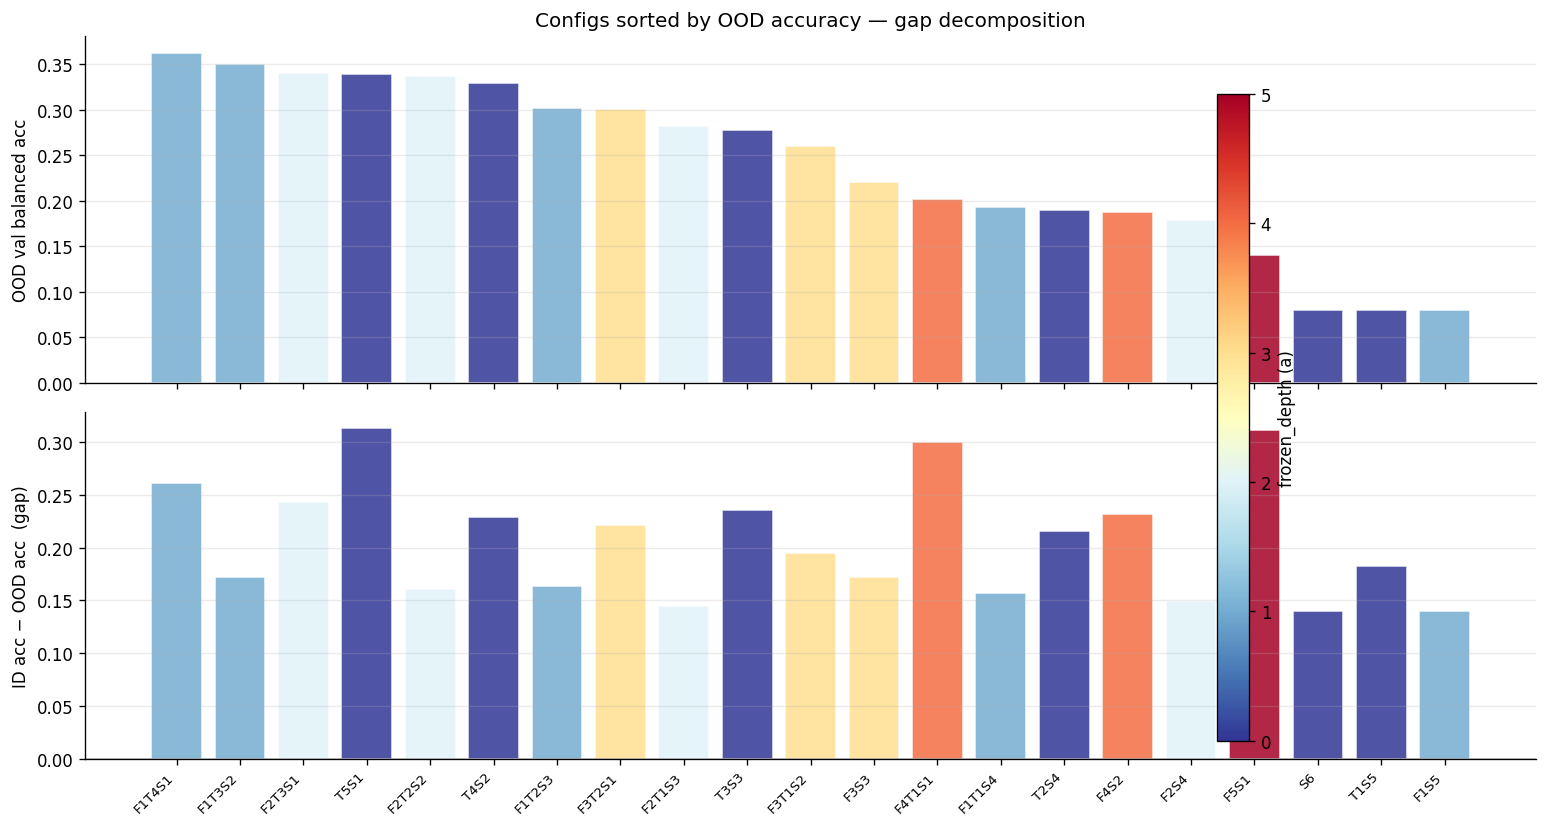

In [9]:
# ── Plot 6: ID–OOD gap per config ─────────────────────────────────────────────
# Smaller gap = the model generalises as well OOD as it does ID.
# Sort by OOD accuracy (best OOD left) to see whether better OOD also means smaller gap.

df_s = df.sort_values('ood_val_bal_acc', ascending=False)
gap  = df_s['id_ood_gap']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

x = np.arange(len(df_s))
bar_colors = [frozen_color(int(df_s.loc[l, 'frozen_depth'])) for l in df_s.index]

axes[0].bar(x, df_s['ood_val_bal_acc'], color=bar_colors, edgecolor='white', alpha=0.85)
axes[0].set_ylabel('OOD val balanced acc')
axes[0].set_title('Configs sorted by OOD accuracy — gap decomposition')
axes[0].grid(True, axis='y', alpha=0.25)

axes[1].bar(x, gap.values, color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_ylabel('ID acc − OOD acc  (gap)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_s.index, rotation=45, ha='right', fontsize=8)
axes[1].grid(True, axis='y', alpha=0.25)

sm = plt.cm.ScalarMappable(cmap=FROZEN_CMAP, norm=FROZEN_NORM)
sm.set_array([])
fig.colorbar(sm, ax=axes, location='right', pad=0.01, label='frozen_depth (a)')

plt.tight_layout()
plt.savefig(RESULTS / 'plot6_id_ood_gap.png', bbox_inches='tight')
plt.show()

C:\Users\tomma\AppData\Local\Temp\ipykernel_8844\3468318738.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


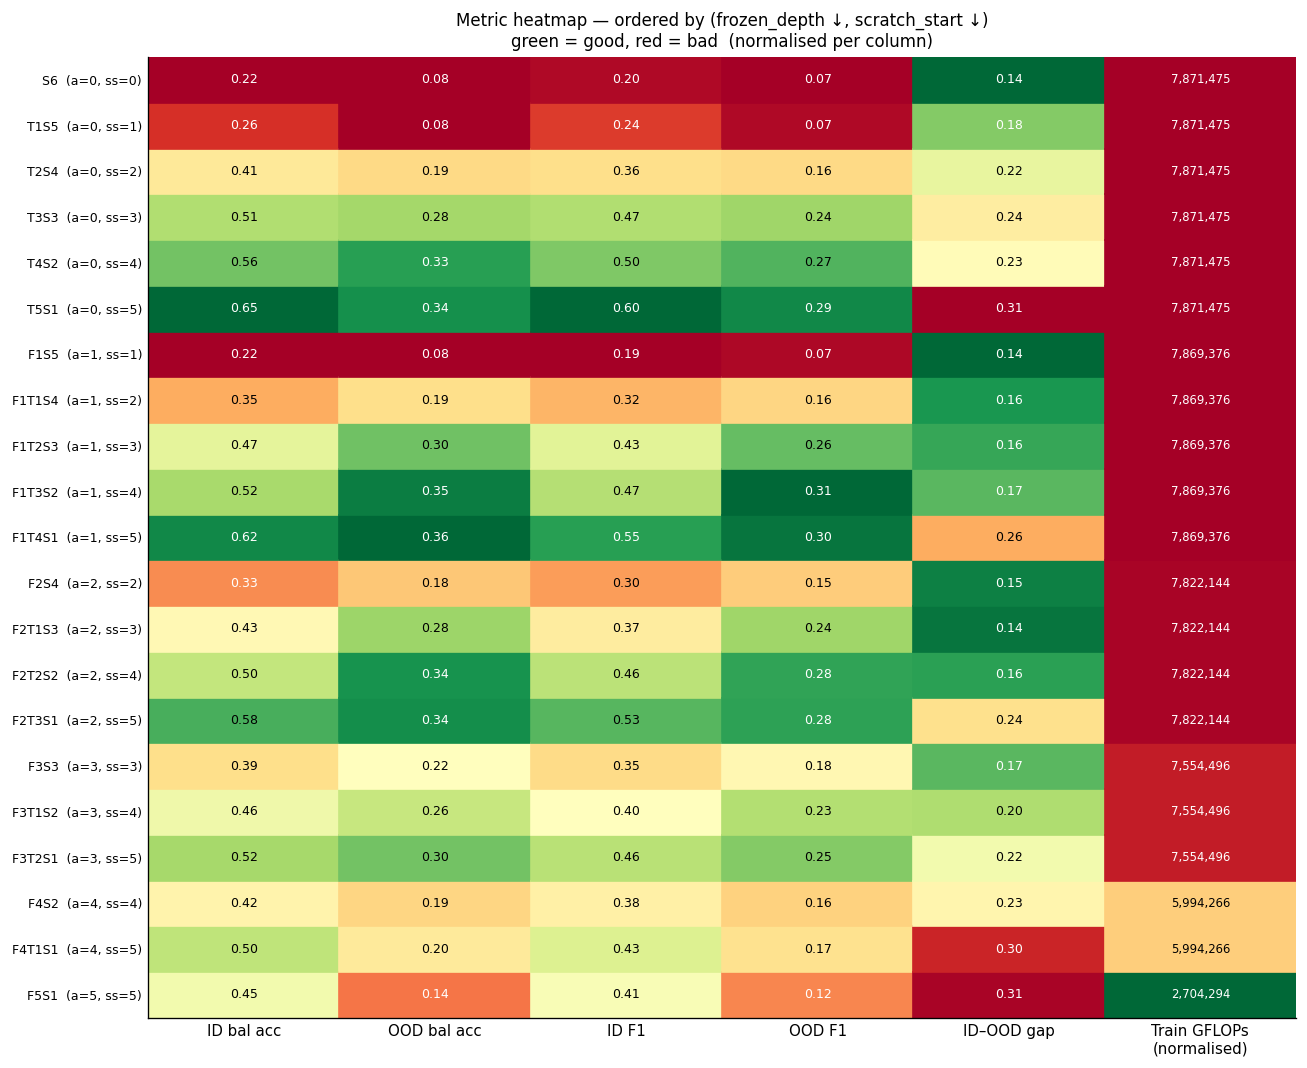

In [10]:
# ── Plot 7: Full metric heatmap ───────────────────────────────────────────────
# Rows = configs ordered by (frozen_depth desc, scratch_start desc)
# Cols = ID bal acc, OOD bal acc, ID F1, OOD F1, ID-OOD gap, total FLOPs (normalised)

col_fields  = ['id_val_bal_acc', 'ood_val_bal_acc', 'id_val_f1', 'ood_val_f1',
               'id_ood_gap', 'total_train_GFLOPs']
col_labels  = ['ID bal acc', 'OOD bal acc', 'ID F1', 'OOD F1',
               'ID–OOD gap', 'Train GFLOPs\n(normalised)']
# Reverse the colour direction for gap and cost (lower = better)
cmaps_per_col = ['RdYlGn','RdYlGn','RdYlGn','RdYlGn','RdYlGn_r','RdYlGn_r']

df_heat = df.sort_values(['frozen_depth','scratch_start'], ascending=[False, False])

# Normalise each column to [0, 1] for display
mat = df_heat[col_fields].copy()
mat_norm = (mat - mat.min()) / (mat.max() - mat.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 9))
for j, (field, cmap_name) in enumerate(zip(col_fields, cmaps_per_col)):
    cmap = plt.cm.get_cmap(cmap_name)
    for i, label in enumerate(df_heat.index):
        val      = mat.loc[label, field]
        val_norm = mat_norm.loc[label, field]
        color    = cmap(val_norm)
        rect = plt.Rectangle([j, i], 1, 1, color=color)
        ax.add_patch(rect)
        txt_color = 'white' if val_norm < 0.25 or val_norm > 0.85 else 'black'
        if field == 'total_train_GFLOPs':
            ax.text(j + 0.5, i + 0.5, f'{int(val):,}', ha='center', va='center',
                    fontsize=7, color=txt_color)
        else:
            ax.text(j + 0.5, i + 0.5, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color=txt_color)

ax.set_xlim(0, len(col_fields))
ax.set_ylim(0, len(df_heat))
ax.set_xticks(np.arange(len(col_fields)) + 0.5)
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(np.arange(len(df_heat)) + 0.5)
ax.set_yticklabels(
    [f'{l}  (a={int(df_heat.loc[l,"frozen_depth"])}, ss={int(df_heat.loc[l,"scratch_start"])})'
     for l in df_heat.index],
    fontsize=7.5
)
ax.set_title('Metric heatmap — ordered by (frozen_depth ↓, scratch_start ↓)\n'
             'green = good, red = bad  (normalised per column)', fontsize=10)
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)

plt.tight_layout()
plt.savefig(RESULTS / 'plot7_heatmap.png', bbox_inches='tight')
plt.show()

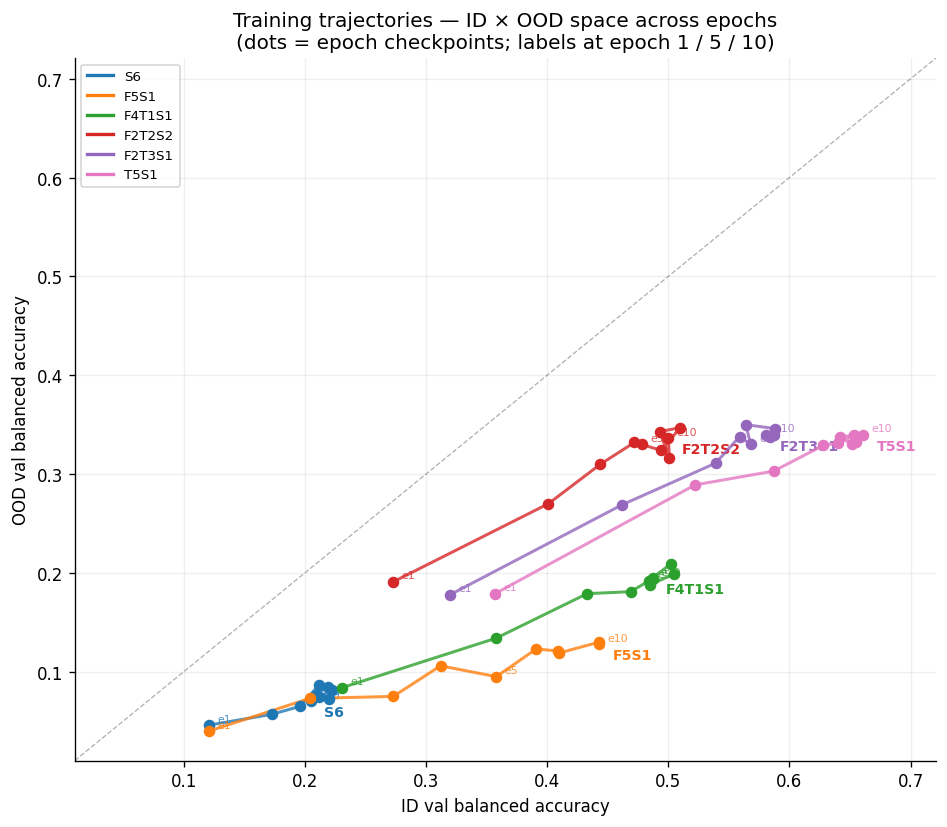

In [11]:
# ── Plot 8: Training trajectories for selected configs ────────────────────────
# Shows how different configs move through ID×OOD space across epochs.
# Useful for spotting early convergence, oscillation, or OOD regression.

SELECTED = ['S6', 'F5S1', 'F4T1S1', 'F2T2S2', 'F2T3S1', 'T5S1']
TRAJ_COLORS = plt.cm.tab10(np.linspace(0, 0.6, len(SELECTED)))

fig, ax = plt.subplots(figsize=(8, 7))

for label, color in zip(SELECTED, TRAJ_COLORS):
    sub = curves[curves['label'] == label].sort_values('epoch')
    ax.plot(sub['id_val_bal_acc'], sub['ood_val_bal_acc'],
            '-', color=color, lw=1.8, alpha=0.8, zorder=3)
    ax.scatter(sub['id_val_bal_acc'], sub['ood_val_bal_acc'],
               color=color, s=35, zorder=4)
    # Epoch labels
    for _, row in sub.iterrows():
        if row['epoch'] in (1, 5, 10):
            ax.annotate(f"e{int(row['epoch'])}",
                        (row['id_val_bal_acc'], row['ood_val_bal_acc']),
                        textcoords='offset points', xytext=(5, 2),
                        fontsize=6.5, color=color, alpha=0.8)
    # Label at final point
    last = sub.iloc[-1]
    ax.annotate(label, (last['id_val_bal_acc'], last['ood_val_bal_acc']),
                textcoords='offset points', xytext=(8, -9),
                fontsize=8.5, color=color, fontweight='bold')

lo = min(curves.loc[curves['label'].isin(SELECTED),
                     ['id_val_bal_acc','ood_val_bal_acc']].min()) - 0.03
hi = max(curves.loc[curves['label'].isin(SELECTED),
                     ['id_val_bal_acc','ood_val_bal_acc']].max()) + 0.06
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.3)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

handles = [Line2D([0],[0], color=c, lw=2, label=l)
           for l, c in zip(SELECTED, TRAJ_COLORS)]
ax.legend(handles=handles, fontsize=8, loc='upper left')
ax.set_xlabel('ID val balanced accuracy')
ax.set_ylabel('OOD val balanced accuracy')
ax.set_title('Training trajectories — ID × OOD space across epochs\n'
             '(dots = epoch checkpoints; labels at epoch 1 / 5 / 10)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(RESULTS / 'plot8_trajectories.png', bbox_inches='tight')
plt.show()

In [12]:
# ── To load real results: replace the two lines below ─────────────────────────
# df     = pd.read_csv(RESULTS / 'spectrum_experiment.csv').set_index('label')
# df['scratch_start'] = df['n_frozen'] + df['n_tuned']
# df['id_ood_gap']    = df['id_val_bal_acc'] - df['ood_val_bal_acc']
# curves = pd.read_csv(RESULTS / 'eval_log_all.csv')    # saved by notebook 04
# Then re-run all plot cells — no other changes needed.
print('Pipeline ready. Swap in real data by following the comments above.')

Pipeline ready. Swap in real data by following the comments above.
